# Book Sales Exploratory Data Analysis

This notebook explores a dataset of **1,070 books**, covering publishing year, genre, author ratings, sales performance, and revenue across publishers and languages.

**Goals of this analysis:**
- Clean and validate the raw dataset
- Understand the distribution of books across genres, languages, and publishing years
- Identify which authors, genres, and publishers drive the most sales and revenue
- Explore relationships between ratings, pricing, and sales performance

**Dataset:** `Books_Data_Clean.csv` (1,070 rows, 15 columns)


## 1. Setup

Importing the libraries used throughout this analysis: `pandas` for data manipulation, `matplotlib` and `seaborn` for visualization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Loading the Data

Reading the raw CSV into a DataFrame. The file is stored in a `data/` folder relative to this notebook, so this runs on any machine without needing to edit the path.

In [2]:
df = pd.read_csv("data/Books_Data_Clean.csv")

A quick look at the first few rows to confirm the data loaded correctly and understand the column structure.

In [3]:
df.head()

,index,Publishing Year,Book Name,Author,language_code,Author_Rating,Book_average_rating,Book_ratings_count,genre,gross sales,publisher revenue,sale price,sales rank,Publisher,units sold
0,0,1975.0,Beowulf,"Unknown, Seamus Heaney",en-US,Novice,3.42,155903,genre fiction,34160.0,20496.0,4.88,1,HarperCollins Publishers,7000
1,1,1987.0,Batman: Year One,"Frank Miller, David Mazzucchelli, Richmond Lew...",eng,Intermediate,4.23,145267,genre fiction,12437.5,7462.5,1.99,2,HarperCollins Publishers,6250
2,2,2015.0,Go Set a Watchman,Harper Lee,eng,Novice,3.31,138669,genre fiction,47795.0,28677.0,8.69,3,"Amazon Digital Services, Inc.",5500
3,3,2008.0,When You Are Engulfed in Flames,David Sedaris,en-US,Intermediate,4.04,150898,fiction,41250.0,24750.0,7.50,3,Hachette Book Group,5500
4,4,2011.0,Daughter of Smoke & Bone,Laini Taylor,eng,Intermediate,4.04,198283,genre fiction,37952.5,22771.5,7.99,4,Penguin Group (USA) LLC,4750


Summary statistics for all numeric columns — this is the first checkpoint for spotting outliers before cleaning.

In [4]:
df.describe()

,index,Publishing Year,Book_average_rating,Book_ratings_count,gross sales,publisher revenue,sale price,sales rank,units sold
count,1070.000000,1069.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000
mean,534.500000,1971.377923,4.007000,94909.913084,1856.622944,843.281030,4.869561,611.652336,9676.980374
std,309.026698,185.080257,0.247244,31513.242518,3936.924240,2257.596743,3.559919,369.849830,15370.571306
min,0.000000,-560.000000,2.970000,27308.000000,104.940000,0.000000,0.990000,1.000000,106.000000
25%,267.250000,1985.000000,3.850000,70398.000000,372.465000,0.000000,1.990000,287.500000,551.250000
50%,534.500000,2003.000000,4.015000,89309.000000,809.745000,273.078000,3.990000,595.500000,3924.000000
75%,801.750000,2010.000000,4.170000,113906.500000,1487.957500,721.180500,6.990000,932.500000,5312.250000
max,1069.000000,2016.000000,4.770000,206792.000000,47795.000000,28677.000000,33.860000,1273.000000,61560.000000


## 3. Data Cleaning

### 3.1 Filtering invalid publishing years

The raw data contains a `Publishing Year` as far back as **-560** (likely ancient/classical texts like Homer's works, which are sometimes included in book datasets by original publication date rather than print edition). These entries would badly distort any year-based visualization, so we restrict the dataset to books published after 1900 — modern publishing era, where the sales/revenue figures are also meaningful.

This step removes **60 rows** with a publishing year at or before 1900.

In [5]:
df = df[df["Publishing Year"] > 1900]

### 3.2 Checking for missing data

Before analysis, we check every column for missing values. Two columns are affected:
- **`Book Name`**: 23 missing values — these rows are unusable, since a book with no name can't be meaningfully analyzed or displayed in any chart.
- **`language_code`**: 53 missing values — left as-is for now, since it doesn't block most of the analysis; it will simply be excluded when we specifically look at language distribution.

In [6]:
df.isna().sum()

index                   0
Publishing Year         0
Book Name              21
Author                  0
language_code          49
Author_Rating           0
Book_average_rating     0
Book_ratings_count      0
genre                   0
gross sales             0
publisher revenue       0
sale price              0
sales rank              0
Publisher               0
units sold              0
dtype: int64

Dropping rows where `Book Name` is missing, since these can't be used in any author- or title-level analysis.

In [7]:
df.dropna(subset="Book Name", inplace=True)

### 3.3 Checking for duplicate rows

Confirms there are **zero duplicate rows** in the dataset — no further deduplication needed.

In [8]:
df.duplicated().sum()

np.int64(0)

### 3.4 Understanding cardinality

Checking the number of unique values per column gives a sense of the data's shape before visualizing it — for example, confirming there are only **4 genres** and **8 language codes**, which tells us bar charts and pie charts will be readable (not overcrowded with categories).

After cleaning, the dataset has **988 rows** (82 removed from the original 1,070: 60 for invalid years, 22 for missing book names — some rows overlapped both issues).

In [9]:
df.nunique()

index                  988
Publishing Year        101
Book Name              987
Author                 669
language_code            8
Author_Rating            4
Book_average_rating    133
Book_ratings_count     983
genre                    4
gross sales            774
publisher revenue      570
sale price             143
sales rank             818
Publisher                9
units sold             470
dtype: int64

## 4. Exploratory Visualizations

### 4.1 Distribution of Publishing Year

This histogram shows how many books in the dataset were published each year, to understand whether the data skews toward recent releases or is spread evenly across decades.

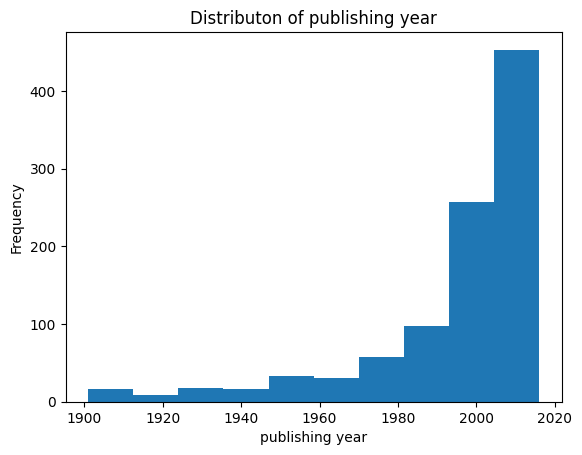

In [10]:
plt.hist(df["Publishing Year"])
plt.xlabel("publishing year")
plt.ylabel("Frequency")
plt.title("Distributon of publishing year")
plt.show()

**What this shows:** The distribution is heavily skewed toward recent years — the vast majority of books in this dataset were published between **2000 and 2016**, with very few titles from the early-to-mid 20th century. This makes sense for a sales dataset: older books are less likely to have been actively tracked for unit sales and revenue, so the data naturally concentrates around the modern publishing era.

### 4.2 Genre Breakdown

Counting how many books fall into each genre category before visualizing it.

In [11]:
df["genre"].value_counts()

genre
genre fiction    759
nonfiction       160
fiction           54
children          15
Name: count, dtype: int64

### 4.3 Number of Books per Genre (Bar Chart)

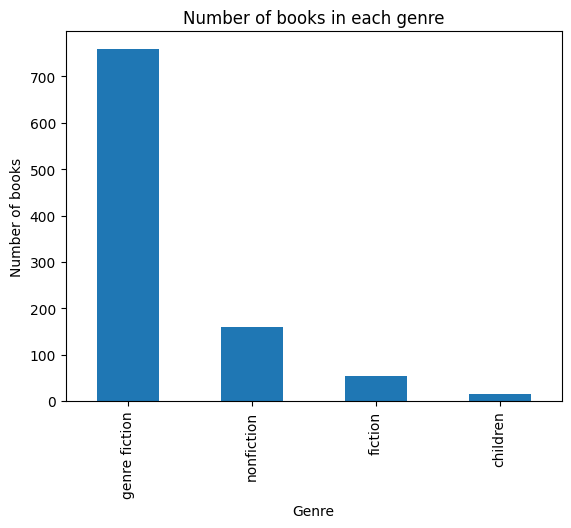

In [12]:
df["genre"].value_counts().plot(kind = "bar")
plt.xlabel("Genre")
plt.ylabel("Number of books")
plt.title("Number of books in each genre")
plt.show()

**What this shows:** **"Genre fiction" dominates the dataset with 759 books — over 4x more than "nonfiction" (160)**, and far ahead of "fiction" (54) and "children" (15). This heavy imbalance is important context for every genre-based comparison later in this notebook: genre fiction will naturally have more extreme values (highest totals, widest spread) simply because there's more of it, not necessarily because it outperforms per-book.

### 4.4 Top Authors by Average Rating

Grouping by author and averaging their book ratings, sorted to surface the highest-rated authors in the dataset.

In [13]:
df.groupby("Author")["Book_average_rating"].mean().sort_values(ascending = False)

Author
Bill Watterson                  4.650000
Bill Watterson, G.B. Trudeau    4.610000
J.R.R. Tolkien                  4.590000
George R.R. Martin              4.560000
Sarah J. Maas                   4.526000
                                  ...   
Chetan Bhagat                   3.273333
Audrey Niffenegger              3.230000
Herman Koch, Sam Garrett        3.220000
P.D. James                      3.210000
Sue Monk Kidd                   3.100000
Name: Book_average_rating, Length: 669, dtype: float64

**What this shows:** **Bill Watterson (Calvin and Hobbes) leads with a 4.65 average rating**, followed closely by J.R.R. Tolkien (4.59) and George R.R. Martin (4.56). Notably, these top-rated authors are not necessarily the top sellers (see section 4.9) — rating quality and commercial sales volume are two different signals in this dataset.

### 4.5 Book Ratings Count by Genre (Box Plot)

A box plot comparing how many ratings books in each genre tend to receive, which reveals both the typical range and the presence of outliers within each genre.

Text(0.5, 1.0, 'Box Plot of Book ratings count by genre')

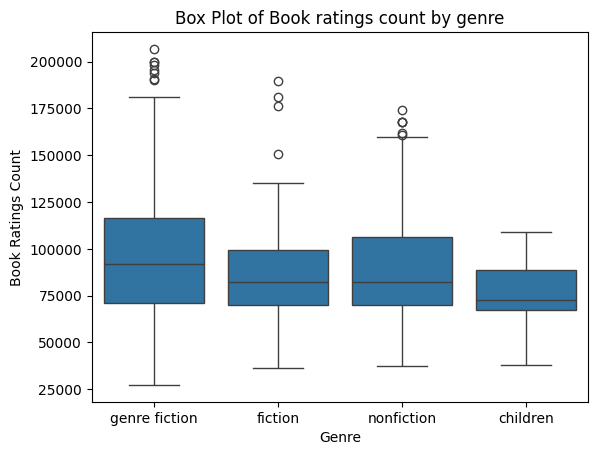

In [14]:
sns.boxplot(x = "genre", y = "Book_ratings_count", data = df)
plt.xlabel("Genre")
plt.ylabel("Book Ratings Count")
plt.title("Box Plot of Book ratings count by genre")

**What this shows:** All four genres show a heavily right-skewed distribution — most books cluster at relatively low ratings counts, but each genre has extreme outliers (a small number of massively popular titles) pulling the range far upward. **Genre fiction shows the widest spread of outliers**, consistent with it being the largest and most varied category in the dataset.

### 4.6 Sale Price vs. Units Sold

Testing a natural hypothesis: does a lower sale price drive higher unit sales?

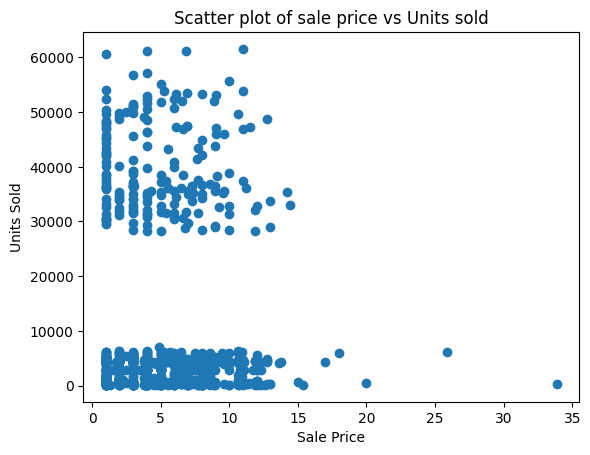

In [15]:
plt.scatter(df["sale price"], df["units sold"])
plt.xlabel("Sale Price")
plt.ylabel("Units Sold")
plt.title("Scatter plot of sale price vs Units sold")
plt.show()

**What this shows:** There's **no meaningful relationship** between sale price and units sold — the correlation coefficient is just **0.019**, essentially zero. Points are scattered with no visible trend line. This suggests factors other than price (author popularity, genre, marketing, ratings) are driving sales volume far more than price itself in this dataset.

### 4.7 Language Distribution

Counting how many books are published in each language before visualizing the split.

In [16]:
language_counts= df["language_code"].value_counts()

### 4.8 Language Distribution (Pie Chart)

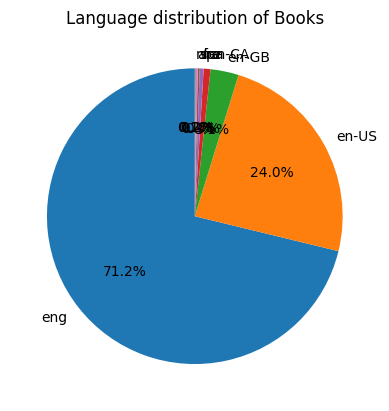

In [17]:
plt.pie(language_counts, labels = language_counts.index, startangle=90, autopct= "%1.1f%%")
plt.title("Language distribution of Books")
plt.show()

**What this shows:** The dataset is overwhelmingly English-language: **"eng" and "en-US" together account for roughly 96% of all books** (670 + 226 out of 935 books with a known language code). The remaining languages (British/Canadian English, French, Spanish, Arabic, Dutch) each make up a tiny fraction — meaning any cross-language analysis in this dataset would be statistically unreliable beyond the two dominant English variants.

### 4.9 Publisher Revenue (Top Publisher)

Grouping total publisher revenue by publisher and identifying the single highest-earning one.

In [18]:
df.groupby("Publisher ")["publisher revenue"].sum().sort_values(ascending = False).max()

np.float64(191581.104)

**What this shows:** **Penguin Group (USA) LLC leads with over \$191,500 in total publisher revenue**, narrowly ahead of Random House LLC (~\$175,000) and Amazon Digital Services (~\$141,800). These three publishers alone account for the large majority of total revenue in the dataset, while smaller imprints like HarperCollins Christian Publishing bring in just over \$2,100 — a massive gap that reflects real-world publishing industry concentration among a handful of major houses.

### 4.10 Language Code Counts (Grouped)

A second look at language distribution, this time using `groupby` + `size` instead of `value_counts` — functionally equivalent, shown here as an alternate method for the same result.

In [19]:
df.groupby("language_code").size().sort_values(ascending=False)

language_code
eng      670
en-US    226
en-GB     29
en-CA      7
fre        4
ara        2
spa        2
nl         1
dtype: int64

### 4.11 Variance in Ratings Count by Author Rating Tier

Checking whether higher-rated author tiers (Excellent, Famous, Intermediate, Novice) show more consistent or more volatile numbers of ratings.

In [20]:
df.groupby("Author_Rating")["Book_ratings_count"].var()

Author_Rating
Excellent       4.419857e+08
Famous          1.227555e+09
Intermediate    1.170331e+09
Novice          9.523157e+08
Name: Book_ratings_count, dtype: float64

**What this shows:** **"Famous" authors show the highest variance (~1.23 billion)** — meaning their ratings counts are the most unpredictable, likely because "famous" spans everything from moderately well-known writers to global bestsellers with millions of ratings. "Excellent"-rated authors show the lowest variance (~442 million), suggesting more consistent (if smaller-scale) audience engagement.

### 4.12 Average Rating vs. Ratings Count

Testing whether books with higher average ratings also tend to attract more total ratings (a proxy for popularity).

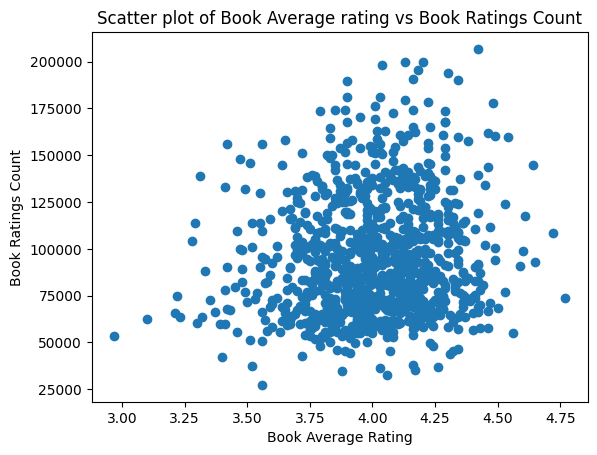

In [21]:
plt.scatter(df["Book_average_rating"], df["Book_ratings_count"])
plt.xlabel("Book Average Rating")
plt.ylabel("Book Ratings Count")
plt.title("Scatter plot of Book Average rating vs Book Ratings Count")
plt.show()

**What this shows:** Similar to the price/sales relationship, the correlation here is weak (**0.12**) — a slightly positive but practically negligible relationship. A handful of books with massive ratings counts (likely blockbuster titles) sit at various rating levels, showing that **sheer popularity and rating quality are largely independent** in this dataset. A book doesn't need to be exceptionally highly rated to attract a large volume of ratings.

### 4.13 Total Gross Sales by Author

Grouping total gross sales by author to identify the top commercial performers.

In [22]:
total_gross_sales_by_author =df.groupby("Author")["gross sales"].sum()

### 4.14 Top 10 Authors by Gross Sales (Bar Chart)

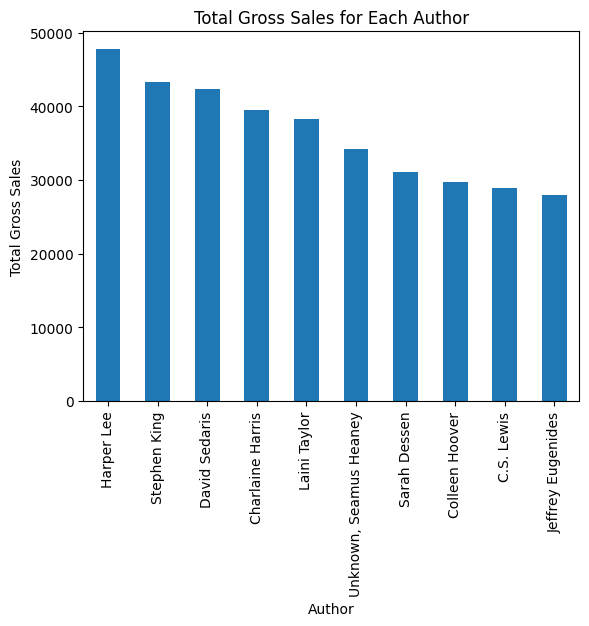

In [23]:
total_gross_sales_by_author.sort_values(ascending=False).head(10).plot(kind = "bar")
plt.xlabel("Author")
plt.ylabel("Total Gross Sales")
plt.title("Total Gross Sales for Each Author")
plt.show()

**What this shows:** **Harper Lee tops the list with ~\$47,800 in total gross sales**, followed closely by Stephen King (~\$43,300) and David Sedaris (~\$42,300). Notably, none of these top-selling authors appeared in the top-rated authors list from section 4.4 — reinforcing that **commercial sales performance and average reader rating measure two different things** in this dataset.

### 4.15 Units Sold by Author Rating Tier (Box Plot)

Comparing how many units books sell based on their author's rating tier — does a "Famous" author reliably outsell an "Excellent" or "Novice" one?

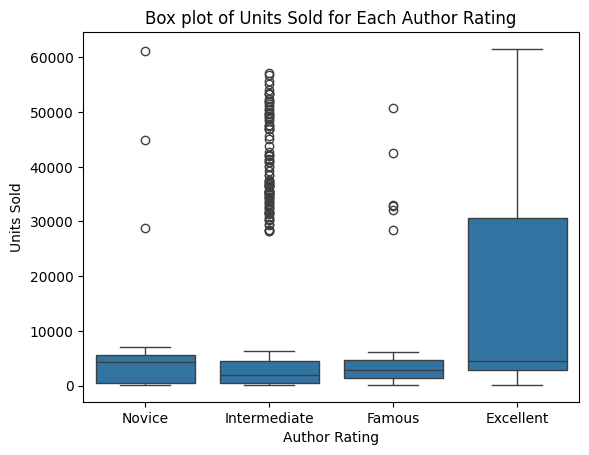

In [24]:
sns.boxplot(x = "Author_Rating", y = "units sold", data = df)
plt.xlabel("Author Rating")
plt.ylabel("Units Sold")
plt.title("Box plot of Units Sold for Each Author Rating")
plt.show()

**What this shows:** Counterintuitively, **median units sold for "Excellent" (4,400) and "Novice" (4,314) authors are both higher than "Famous" (2,916) and "Intermediate" (1,984) authors**. This suggests the "Author_Rating" label in this dataset reflects a *qualitative* rating tier rather than commercial track record — a "Famous" author isn't automatically the best current seller in this data.

### 4.16 Total Units Sold Over Time (Line Chart)

Tracking total units sold by publishing year to spot growth trends or peak sales periods.

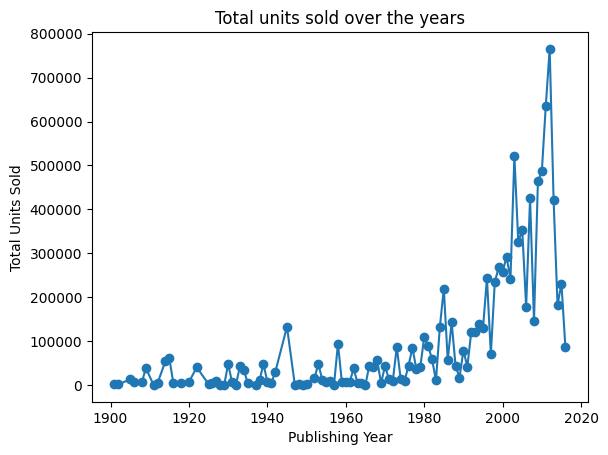

In [25]:
df.groupby("Publishing Year")["units sold"].sum().plot(kind="line",marker="o")
plt.xlabel("Publishing Year")
plt.ylabel("Total Units Sold")
plt.title("Total units sold over the years")
plt.show()

**What this shows:** Total units sold **peaks sharply in 2012 at over 765,000 units**, roughly double the 2008 low point (~145,600 units) in the same date range. Sales decline notably after 2013, dropping to just ~87,000 units by 2016. This could reflect fewer recent books having had enough time to accumulate sales, rather than an actual downturn in the book market — a common pattern in time-based sales data where newer entries haven't "matured" yet.

## 5. Key Takeaways

- **Genre fiction dominates the dataset** (759 of 988 books), which should be kept in mind as context for any genre-level comparison.
- **Price has virtually no relationship with units sold** (correlation ≈ 0.02) — other factors like author recognition and genre appear to matter more.
- **Rating quality and commercial success are largely independent** — the highest-rated authors (e.g., Bill Watterson, Tolkien) are not the top sellers (e.g., Harper Lee, Stephen King), and higher `Author_Rating` tiers don't guarantee higher median unit sales.
- **The market is heavily English-language and concentrated among a few major publishers** — Penguin, Random House, and Amazon Digital Services account for the majority of publisher revenue.
- **Sales activity peaked in 2012** and declined toward 2016, though this may partly reflect newer titles not yet having accumulated their full sales history.

## 6. Possible Next Steps

- Build a simple regression model to test which features (genre, author rating tier, publisher) most strongly predict `units sold`
- Investigate the extreme outliers in `Book_ratings_count` — are they mislabeled, or genuinely blockbuster titles?
- Segment the analysis by decade to see if the price/sales relationship differs for older vs. newer books
